# Prodigy InfoTech Data Science Internship — Task 02

**Submitted by:** Sudip Mitra  
**Track:** Data Science  
**Task:** 02 — Data Cleaning and Exploratory Data Analysis (EDA)


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [41]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [42]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [43]:
df.shape

(891, 12)

In [44]:
df = df.drop("Cabin", axis=1)

In [45]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [46]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [47]:
df.isnull().sum().sum()

np.int64(0)

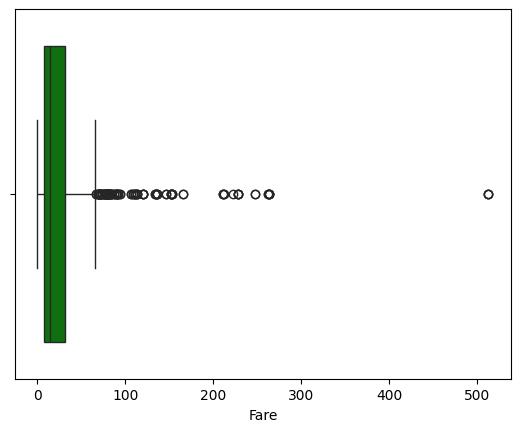

In [48]:
sns.boxplot(x=df["Fare"],color="g")
plt.show()

In [51]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("Outliers before:", len(df[
    (df["Fare"] < lower_bound) |
    (df["Fare"] > upper_bound)
]))

Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344
Outliers before: 116


In [52]:
df = df[
    (df["Fare"] >= lower_bound) &
    (df["Fare"] <= upper_bound)
]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (775, 11)


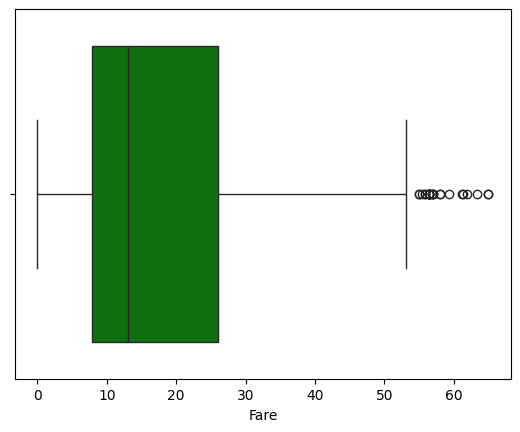

In [53]:
sns.boxplot(x=df["Fare"],color="g")
plt.show()

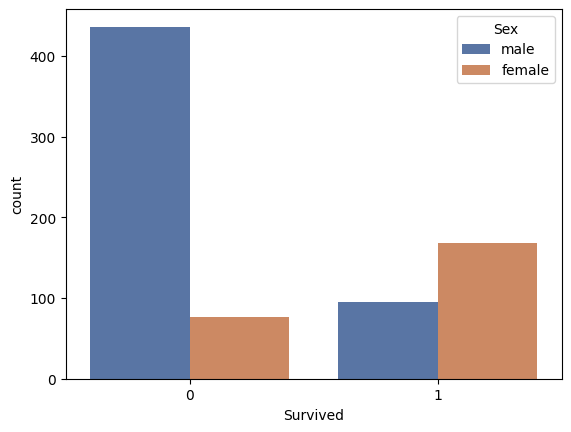

In [74]:
sns.countplot(x="Survived",hue="Sex", data=df,color="y",alpha=1,palette="deep")
plt.show()

In [54]:
print(df.duplicated().sum())

0


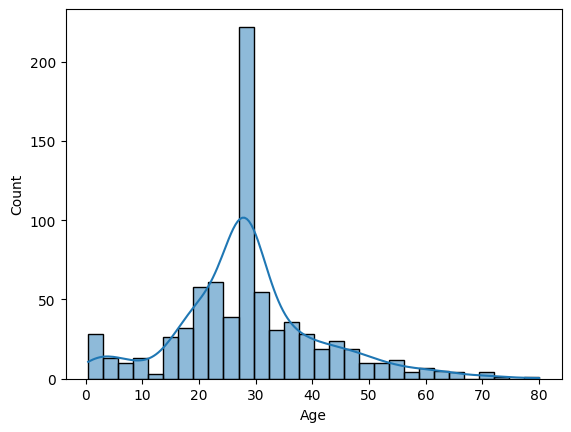

In [60]:
sns.histplot(df["Age"], bins=30, kde=True,legend="Full")
plt.show()

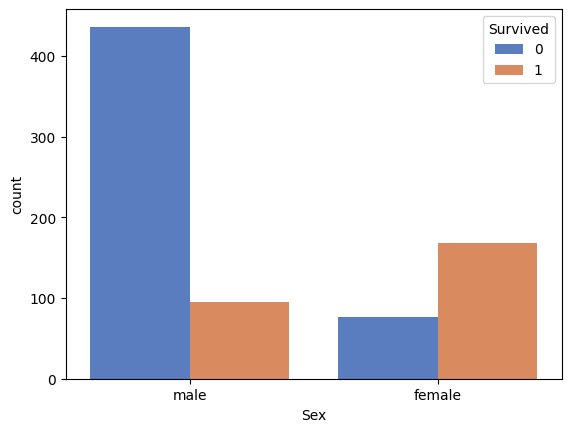

In [72]:
sns.countplot(x="Sex", hue="Survived", data=df,palette="muted")
plt.show()

In [ ]:
# Survival by Passenger Class

plt.figure(figsize=(8, 5))
sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()


In [ ]:
# Survival by Age

plt.figure(figsize=(8, 5))
sns.boxplot(x="Survived", y="Age", data=df)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()


## Conclusion and Observations

- The Titanic dataset was successfully cleaned by handling missing values.
- Missing Age values were replaced using the median.
- Missing Embarked values were replaced using the mode.
- The Cabin column was removed because it contained a large number of missing values.
- Fare outliers were detected using the IQR method and removed.
- The visualizations show relationships between survival and passenger characteristics such as Sex, Passenger Class, and Age.
- These visualizations help identify patterns in passenger survival.


In [75]:
print(df.groupby("Sex")["Survived"].mean())

Sex
female    0.688525
male      0.178908
Name: Survived, dtype: float64


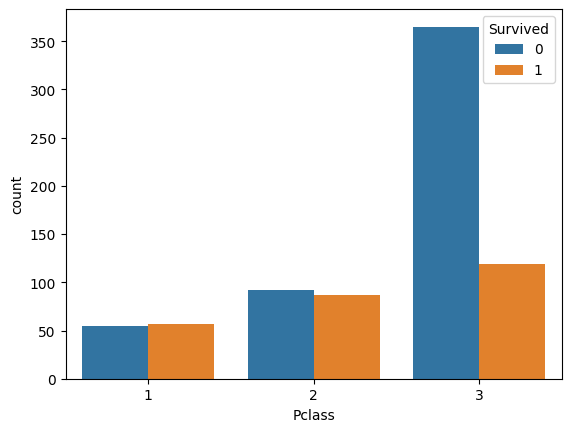

In [77]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.show()

In [78]:
print(df.groupby("Pclass")["Survived"].mean())

Pclass
1    0.508929
2    0.486034
3    0.245868
Name: Survived, dtype: float64


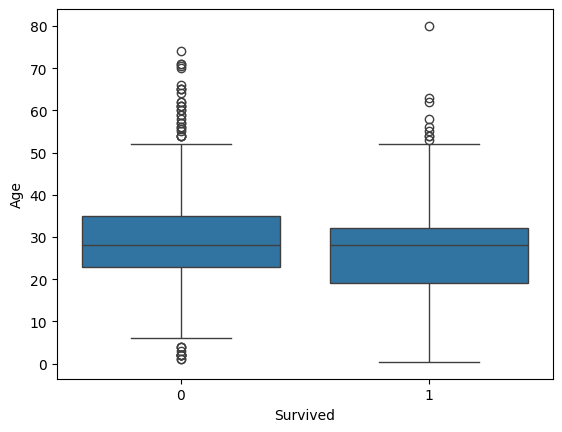

In [79]:
sns.boxplot(x="Survived", y="Age", data=df)
plt.show()

In [80]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

In [81]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Young Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Young Adult
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q,Young Adult
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,Young Adult
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,Young Adult
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,Young Adult
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,Young Adult


In [82]:
print(df.groupby("AgeGroup", observed=True)["Survived"].mean())

AgeGroup
Child          0.569231
Teen           0.366667
Young Adult    0.323591
Adult          0.300654
Senior         0.166667
Name: Survived, dtype: float64


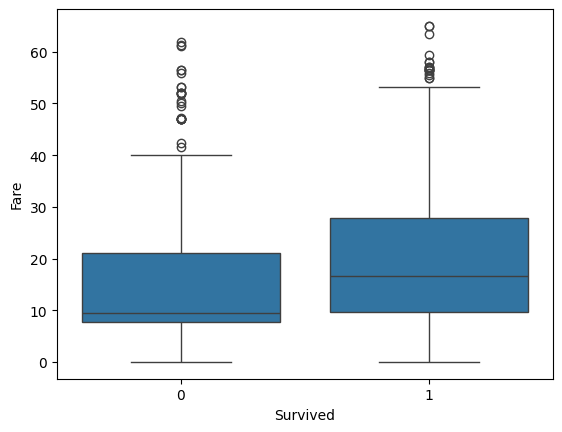

In [83]:
sns.boxplot(x="Survived", y="Fare", data=df)
plt.show()

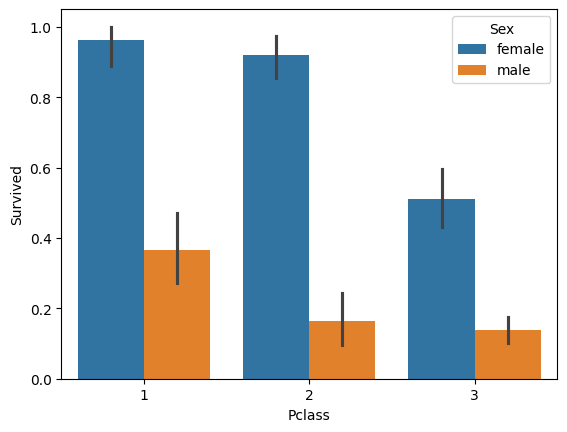

In [84]:
sns.barplot(
    x="Pclass",
    y="Survived",
    hue="Sex",
    data=df
)

plt.show()

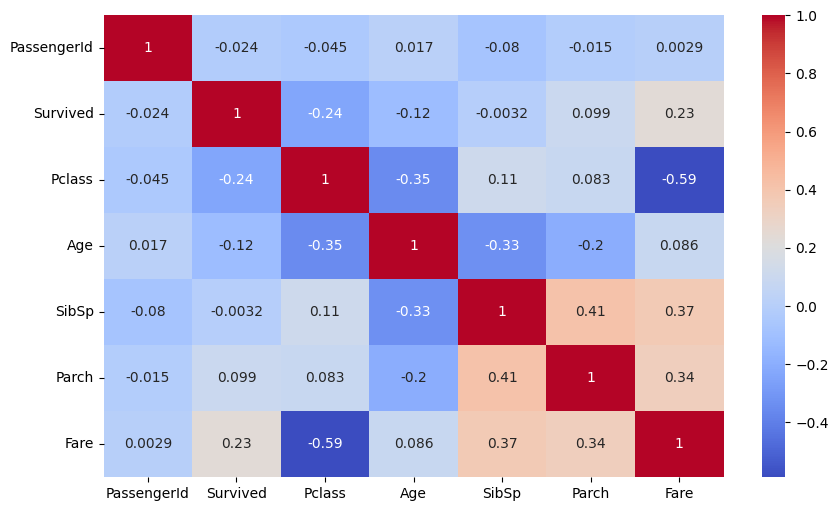

In [85]:
correlation = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.show()

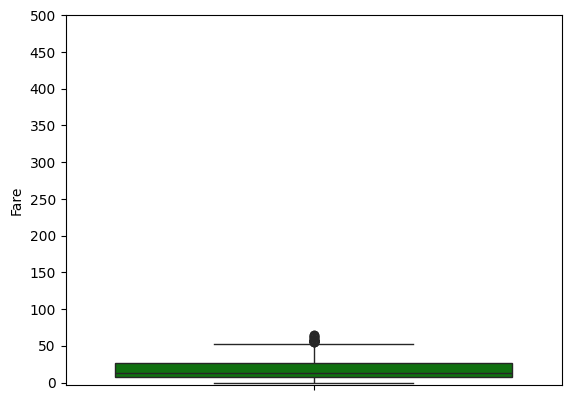

In [89]:
sns.boxplot(y=df["Fare"], color="g")
plt.yticks([0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500])
plt.ylabel("Fare")
plt.show()